# Scary Stochastics, Week 1: Markov Chains
## Notebook 1 of 3 — Synthetic Pumpkin Harvest Data

We're building a 10-year synthetic pumpkin harvest record, then discretizing it into four harvest categories (**Poor, Average, Good, Bumper**) that will become the states of a Markov chain in Notebook 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Harvest / Halloween color palette
HARVEST = {
    "poor":    "#3B2145",  # deep purple  - a rough year
    "average": "#B5451B",  # burnt orange/rust
    "good":    "#E8741C",  # pumpkin orange
    "bumper":  "#D9A404",  # golden mustard - the best years
    "black":   "#1B1B1B",
    "cream":   "#FBF3E1",
}

CATS = ["Poor", "Average", "Good", "Bumper"]
CAT_COLORS = [HARVEST["poor"], HARVEST["average"], HARVEST["good"], HARVEST["bumper"]]

plt.rcParams.update({
    "figure.facecolor": HARVEST["cream"],
    "axes.facecolor": HARVEST["cream"],
    "axes.edgecolor": HARVEST["black"],
    "text.color": HARVEST["black"],
    "axes.labelcolor": HARVEST["black"],
    "xtick.color": HARVEST["black"],
    "ytick.color": HARVEST["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Generate the 10-year synthetic harvest

In [2]:
# Synthetic 10-year pumpkin harvest (tons/acre)
years = np.arange(2016, 2026)
base_yield = 15
yields_ = base_yield + np.random.normal(0, 4, size=10)
yields_ = np.clip(yields_, 3, None).round(1)

harvest_df = pd.DataFrame({"Year": years, "Yield_tons_per_acre": yields_})
harvest_df["Category"] = pd.qcut(harvest_df["Yield_tons_per_acre"], q=4, labels=CATS)
harvest_df

,Year,Yield_tons_per_acre,Category
0,2016,17.0,Average
1,2017,14.4,Average
2,2018,17.6,Good
3,2019,21.1,Bumper
4,2020,14.1,Poor
5,2021,14.1,Poor
6,2022,21.3,Bumper
7,2023,18.1,Bumper
8,2024,13.1,Poor
9,2025,17.2,Good


### Visual 1 — Yearly yields

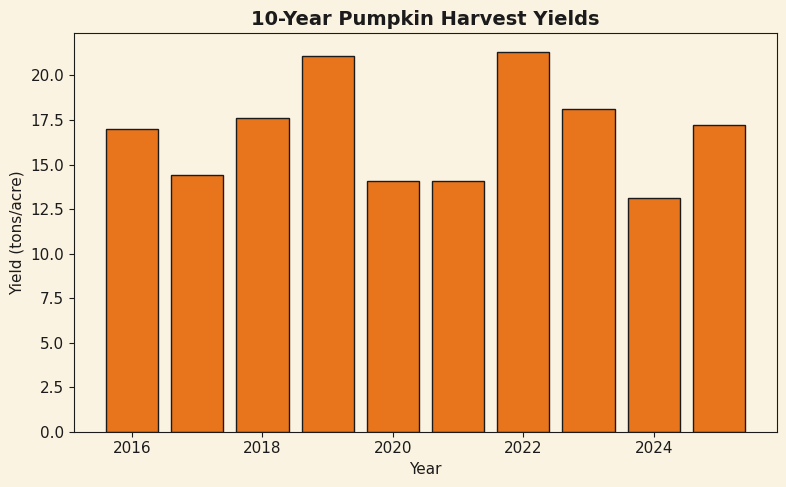

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(harvest_df["Year"], harvest_df["Yield_tons_per_acre"],
       color=HARVEST["good"], edgecolor=HARVEST["black"])
ax.set_title("10-Year Pumpkin Harvest Yields")
ax.set_xlabel("Year")
ax.set_ylabel("Yield (tons/acre)")
plt.tight_layout()
plt.savefig("01_harvest_yields.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Visual 2 — Category distribution

With only 10 years of data, quartile binning guarantees a roughly even spread across the four states — worth remembering when we build the transition matrix next notebook, since 10 years means only 9 observed transitions.

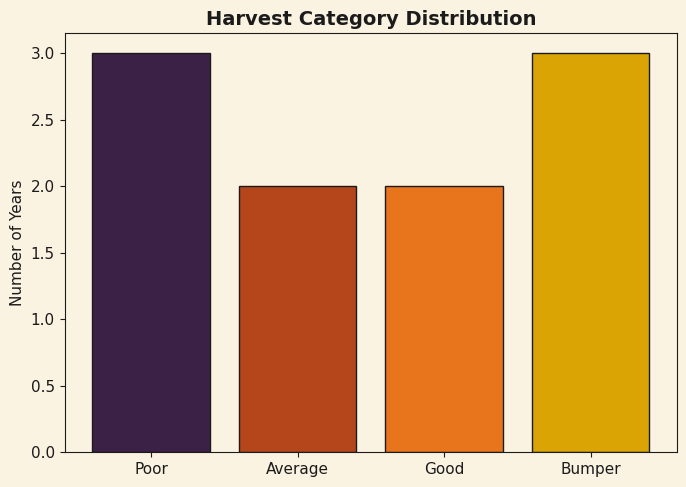

In [4]:
counts = harvest_df["Category"].value_counts().reindex(CATS)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(CATS, counts.values, color=CAT_COLORS, edgecolor=HARVEST["black"])
ax.set_title("Harvest Category Distribution")
ax.set_ylabel("Number of Years")
plt.tight_layout()
plt.savefig("02_category_distribution.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Save for Notebook 2

In [5]:
harvest_df.to_csv("pumpkin_harvest_10yr.csv", index=False)
harvest_df

,Year,Yield_tons_per_acre,Category
0,2016,17.0,Average
1,2017,14.4,Average
2,2018,17.6,Good
3,2019,21.1,Bumper
4,2020,14.1,Poor
5,2021,14.1,Poor
6,2022,21.3,Bumper
7,2023,18.1,Bumper
8,2024,13.1,Poor
9,2025,17.2,Good
